F2-score Logistic Regression: [0.94327872 0.35714286 0.         0.         0.         0.
 0.         0.85714286 0.         0.42094456 0.         0.56603774
 0.         0.16865079 0.         0.546875   0.         0.
 0.         0.         0.         0.22875817 0.         0.
 0.         0.         0.        ]
F2-score Random Forest: [0.9383312  0.51351351 0.26785714 0.         0.         0.
 0.         0.8913649  0.83333333 0.8287796  0.66666667 0.77586207
 0.         0.39377289 0.08474576 0.87581699 0.         0.09202454
 0.13245033 0.         0.37037037 0.41401274 0.         0.
 0.         0.03937008 0.13986014]

Logistic Regression Classification Report (3 clases principales):
              precision    recall  f1-score   support

hyperthyroid       0.99      0.98      0.98      2011
 hypothyroid       0.75      0.33      0.46        36
    negative       0.00      0.00      0.00        11

   micro avg       0.99      0.96      0.97      2058
   macro avg       0.58      0.44      0.

d:\Documentos_TheReal\IA\PIA\Apuntes\Segunda Evaluación\ia25-master-main\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Documentos_TheReal\IA\PIA\Apuntes\Segunda Evaluación\ia25-master-main\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Documentos_TheReal\IA\PIA\Apuntes\Segunda Evaluación\ia25-master-main\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

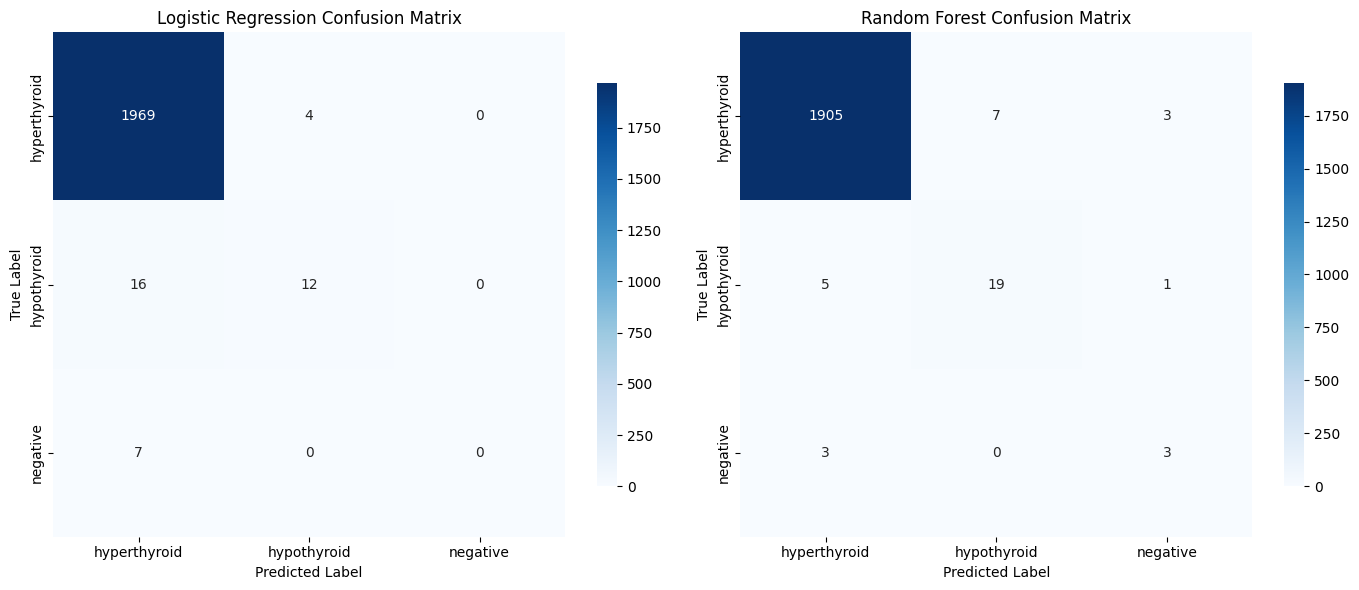


Resumen de resultados:
Número de muestras en el conjunto de prueba: 2752
Número de muestras con las 3 clases principales: 2058
Número de muestras con otras clases (excluidas): 694


In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
data_tiroides = pd.read_csv('data/thyroidDF.csv')

# Eliminar filas con valores nulos en la columna 'age'
data_tiroides = data_tiroides.dropna(subset=["age"])

# Seleccionar las variables relevantes para el modelo
X = data_tiroides[["TSH", "T3", "TT4", "age"]]
y = data_tiroides["target"]

# Guardar las etiquetas originales antes de codificar
original_classes = pd.unique(y)

# Codificar las etiquetas de target a valores numéricos
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convertir columnas categóricas a numéricas (F -> 0, T -> 1)
def convert_categorical_to_numeric(dataframe):
    for col in dataframe.select_dtypes(include='object').columns:
        if dataframe[col].nunique() == 2:
            dataframe[col] = dataframe[col].map({'F': 0, 'T': 1})
        else:
            dataframe[col] = dataframe[col].astype('category').cat.codes
    return dataframe

# Aplicar la conversión categórica antes del preprocesamiento
X = convert_categorical_to_numeric(X.copy())

# Crear el pipeline para Logistic Regression
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Crear el pipeline para Random Forest
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        random_state=42,
        n_jobs=-1
    ))
])

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Entrenar y evaluar Logistic Regression
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

# Entrenar y evaluar Random Forest
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

# Definir las 3 clases principales
main_classes = np.array([0, 1, 2])
main_class_names = ['hyperthyroid', 'hypothyroid', 'negative']

# Evaluar el F2 score
f2_per_class_lr = fbeta_score(y_test, y_pred_lr, beta=2, average=None)
f2_per_class_rf = fbeta_score(y_test, y_pred_rf, beta=2, average=None)

# Mostrar F2-score para ambos modelos
print(f"F2-score Logistic Regression: {f2_per_class_lr}")
print(f"F2-score Random Forest: {f2_per_class_rf}")

# Filtrar solo las 3 clases de interés para los reportes
mask_test = np.isin(y_test, main_classes)
y_test_filtered = y_test[mask_test]
y_pred_lr_filtered = y_pred_lr[mask_test]
y_pred_rf_filtered = y_pred_rf[mask_test]

# Reporte de clasificación para Logistic Regression (solo 3 clases principales)
print("\n" + "="*80)
print("Logistic Regression Classification Report (3 clases principales):")
print("="*80)
print(classification_report(y_test_filtered, y_pred_lr_filtered, 
                          labels=main_classes, target_names=main_class_names))

print("Logistic Regression Confusion Matrix (3 clases principales):")
cm_lr = confusion_matrix(y_test_filtered, y_pred_lr_filtered, labels=main_classes)
print(cm_lr)

# Reporte de clasificación para Random Forest (solo 3 clases principales)
print("\n" + "="*80)
print("Random Forest Classification Report (3 clases principales):")
print("="*80)
print(classification_report(y_test_filtered, y_pred_rf_filtered, 
                          labels=main_classes, target_names=main_class_names))

print("Random Forest Confusion Matrix (3 clases principales):")
cm_rf = confusion_matrix(y_test_filtered, y_pred_rf_filtered, labels=main_classes)
print(cm_rf)

# Crear las matrices de confusión en gráfico de calor (solo 3 clases principales)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=main_class_names, 
            yticklabels=main_class_names, 
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=main_class_names, 
            yticklabels=main_class_names, 
            ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Ajustar los espacios entre los gráficos
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Resumen de resultados:")
print("="*80)
print(f"Número de muestras en el conjunto de prueba: {len(y_test)}")
print(f"Número de muestras con las 3 clases principales: {len(y_test_filtered)}")
print(f"Número de muestras con otras clases (excluidas): {len(y_test) - len(y_test_filtered)}")